# `mvkit`: a guided tour

`mvkit` is a small Rust + Python library for simulating McKean-Vlasov
SDEs and solving Mean Field Games. The Rust core handles the
particle inner loop (parallel particle update, deterministic noise
sampling, reproducibility); Python wraps it with an ergonomic API
plus a set of pure-Python utilities for propagation-of-chaos rate
estimation, strong-error testing, and Mean Field Game solvers (both
closed-form and grid-based).

This notebook is the single best entry point to the library. It
walks through:

1. The four built-in particle models (LQ, Cucker-Smale, Kuramoto,
   mean-field CIR), each chosen to highlight a different aspect of
   the mean-field machinery.
2. Quantitative validation tools: propagation-of-chaos rate
   estimation (Fournier-Guillin) and strong-error rates via shared
   Brownian paths.
3. Mean Field Games: the scalar closed-form LQ solver, the vector
   LQ solver via the matrix Riccati ODE, and the generic non-LQ
   grid solver in 1D and 2D (with periodic and Neumann boundary
   conditions, isotropic and anisotropic diffusion).
4. A small applied vignette on a basket of correlated CIR variance
   processes.

Audience: quantitative researchers and applied probabilists
comfortable with basic stochastic calculus. Reading time: about 45
to 60 minutes.

## Setup

A single seed convention: every simulation in this notebook is
reproducible. Pass `seed=...` to any `simulate_*` function and
identical inputs give bit-exact identical outputs, regardless of
thread count.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import mvkit
from mvkit import (
    simulate_cucker_smale,
    simulate_kuramoto,
    simulate_linear_quadratic,
    simulate_mean_field_cir,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110})

print(f"mvkit {mvkit.__version__}, numpy {np.__version__}")

mvkit 0.1.0, numpy 2.4.4


## 1. The linear-quadratic McKean-Vlasov model

The simplest non-trivial mean-field SDE: scalar state, linear drift
coupling self and population mean, additive noise.

$$
\mathrm{d}X_t = (a\, X_t + b\, \bar X_t)\, \mathrm{d}t + \sigma\, \mathrm{d}W_t,
\qquad X_0 \sim \mathcal{N}(m_0, v_0).
$$

Because the drift is linear and the noise is additive, the marginal
law stays Gaussian for all $t$, with closed-form moments:

$$
m(t) = m_0 \exp\big((a + b)\, t\big), \qquad
v(t) = v_0 \exp(2 a t) + \sigma^2 \frac{\exp(2 a t) - 1}{2 a}.
$$

These exact moments make LQ the canonical correctness benchmark for
any mean-field integrator.

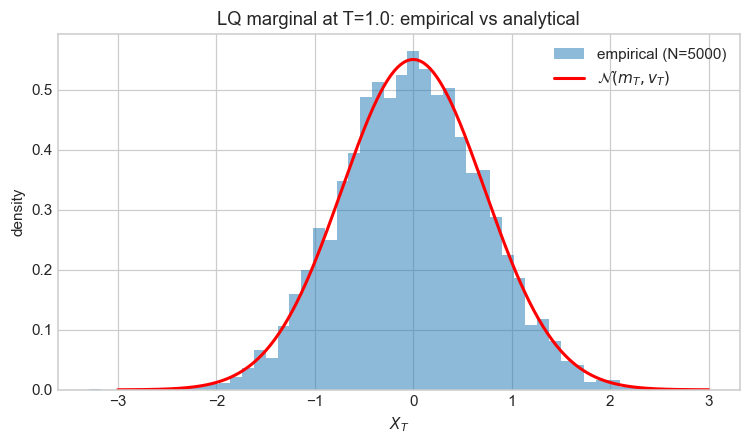

analytical m_T = 0.0000, v_T = 0.5259
empirical m_T = -0.0094, v_T = 0.5219


In [2]:
n, T, n_steps = 5000, 1.0, 2000
a, b, sigma = -0.5, 1.0, 0.5
m_0, v_0 = 0.0, 1.0

rng = np.random.default_rng(0)
x0 = rng.normal(m_0, np.sqrt(v_0), size=(n, 1))
hist = simulate_linear_quadratic(
    x0, t_final=T, n_steps=n_steps, a=a, b=b, sigma=sigma, seed=0
)

m_T = m_0 * np.exp((a + b) * T)
v_T = v_0 * np.exp(2 * a * T) + sigma**2 * (np.exp(2 * a * T) - 1) / (2 * a)

xs = np.linspace(-3.0, 3.0, 400)
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(hist[-1, :, 0], bins=50, density=True, alpha=0.5,
        color="tab:blue", label=f"empirical (N={n})")
ax.plot(xs, norm(loc=m_T, scale=np.sqrt(v_T)).pdf(xs),
        "r-", lw=2, label=rf"$\mathcal{{N}}(m_T, v_T)$")
ax.set_xlabel(r"$X_T$")
ax.set_ylabel("density")
ax.set_title(f"LQ marginal at T={T}: empirical vs analytical")
ax.legend()
plt.show()

print(f"analytical m_T = {m_T:.4f}, v_T = {v_T:.4f}")
print(f"empirical m_T = {hist[-1, :, 0].mean():.4f}, "
      f"v_T = {hist[-1, :, 0].var():.4f}")

The empirical histogram tracks the analytical Gaussian density to
within Monte Carlo noise. With `a + b = 0.5 > 0` the mean drifts
to the right; with `a < 0` the variance stabilizes around
`sigma^2 / (-2a) = 0.25` rather than blowing up.

## 2. Cucker-Smale flocking

A model of self-organizing collective motion: particles in
$\mathbb{R}^d$ with positions $x_i$ and velocities $v_i$, aligning
their velocities through a long-range kernel:

$$
\mathrm{d}x_i = v_i\, \mathrm{d}t,
\qquad
\mathrm{d}v_i = \frac{1}{N}\sum_{j=1}^N K(\lvert x_j - x_i \rvert)\,(v_j - v_i)\, \mathrm{d}t + \sigma\, \mathrm{d}W_i,
$$

with kernel $K(r) = (1 + r^2)^{-\beta}$. The deterministic part
conserves the mean velocity $\bar v = \tfrac{1}{N}\sum v_i$, which
is the textbook sanity check on any integrator. For $\beta < 1/2$,
velocities concentrate around $\bar v$ unconditionally
(Cucker and Smale 2007).

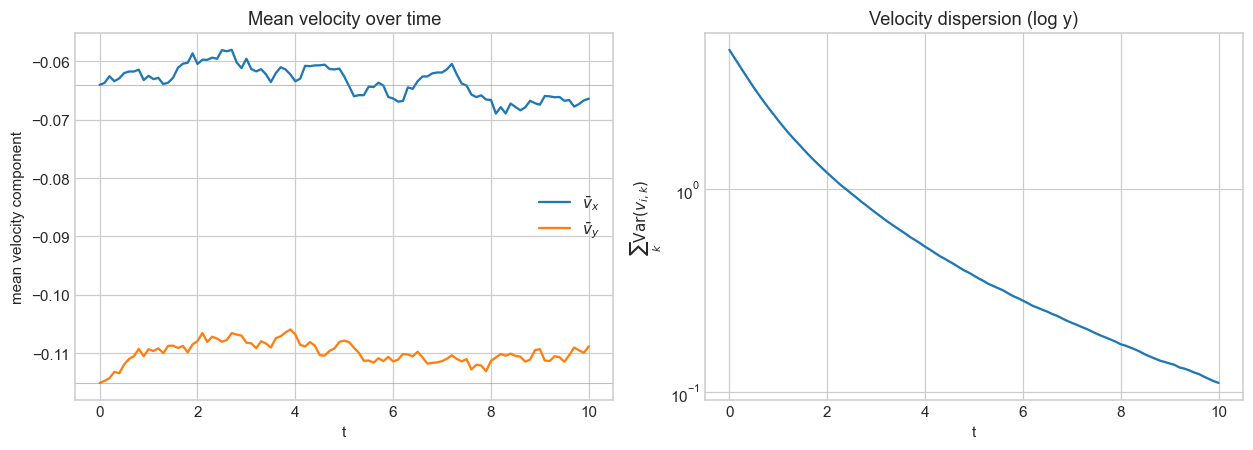

max drift in mean velocity over the run: 0.0092
residual MC fluctuation expected (sigma sqrt(T/N) ~ 0.0091)


In [3]:
rng = np.random.default_rng(1)
n_cs, d = 300, 2
x0_cs = np.empty((n_cs, 2 * d))
x0_cs[:, :d] = rng.normal(scale=2.0, size=(n_cs, d))
x0_cs[:, d:] = rng.normal(scale=1.5, size=(n_cs, d))

history = simulate_cucker_smale(
    x0_cs, t_final=10.0, n_steps=2000, spatial_dim=d,
    beta=0.4, sigma=0.05, record_every=20, seed=1,
)
times = np.linspace(0.0, 10.0, history.shape[0])

vel = history[..., d:]
mean_vel = vel.mean(axis=1)
vel_disp = vel.var(axis=1).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot(times, mean_vel[:, 0], label=r"$\bar v_x$")
axes[0].plot(times, mean_vel[:, 1], label=r"$\bar v_y$")
axes[0].axhline(mean_vel[0, 0], color="grey", lw=0.7, alpha=0.5)
axes[0].axhline(mean_vel[0, 1], color="grey", lw=0.7, alpha=0.5)
axes[0].set_xlabel("t")
axes[0].set_ylabel("mean velocity component")
axes[0].set_title("Mean velocity over time")
axes[0].legend()
axes[1].semilogy(times, vel_disp, color="tab:blue")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$\sum_k \mathrm{Var}(v_{i,k})$")
axes[1].set_title("Velocity dispersion (log y)")
plt.tight_layout()
plt.show()

drift = float(np.max(np.abs(mean_vel - mean_vel[0])))
print(f"max drift in mean velocity over the run: {drift:.4f}")
print(f"residual MC fluctuation expected (sigma sqrt(T/N) ~ {0.05 * np.sqrt(10/n_cs):.4f})")

Left panel: the mean velocity stays flat (the small wiggle is from
the diffusion, of order $\sigma \sqrt{T/N}$). Right panel: the
velocity dispersion decays exponentially, classic flocking behaviour
with $\beta < 1/2$.

## 3. Kuramoto and the synchronization transition

Phase oscillators on the circle, with heterogeneous natural
frequencies $\omega_i$ and all-to-all coupling:

$$
\mathrm{d}\theta_i = \omega_i\, \mathrm{d}t
+ \frac{K}{N}\sum_{j=1}^N \sin(\theta_j - \theta_i)\, \mathrm{d}t + \sigma\, \mathrm{d}W_i.
$$

Synchronization is captured by the order parameter
$r(t) = \big| \tfrac{1}{N} \sum_j e^{i\theta_j(t)} \big|$. For
Gaussian $\omega_i \sim \mathcal{N}(0, \sigma_\omega^2)$ the critical
coupling is

$$
K_c = 2\, \sigma_\omega \sqrt{2/\pi}.
$$

Below $K_c$ the population stays incoherent ($r \to 0$ as
$N \to \infty$); above $K_c$ a fraction of oscillators lock and
$r$ stabilizes between 0 and 1.

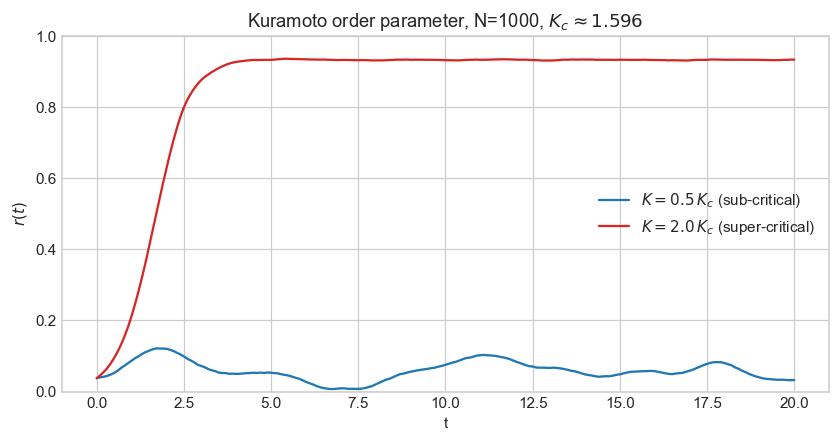

In [4]:
rng = np.random.default_rng(2)
n_kur = 1000
sigma_omega = 1.0
omegas = rng.normal(scale=sigma_omega, size=n_kur)
K_c = 2.0 * sigma_omega * np.sqrt(2.0 / np.pi)

x0_kur = rng.uniform(-np.pi, np.pi, size=(n_kur, 1))


def order_parameter(theta_history):
    return np.abs(np.exp(1j * theta_history[..., 0]).mean(axis=1))


hist_sub = simulate_kuramoto(
    x0_kur, t_final=20.0, n_steps=4000, coupling_k=0.5 * K_c,
    omegas=omegas, sigma=0.1, record_every=20, seed=2,
)
hist_sup = simulate_kuramoto(
    x0_kur, t_final=20.0, n_steps=4000, coupling_k=2.0 * K_c,
    omegas=omegas, sigma=0.1, record_every=20, seed=3,
)
times_k = np.linspace(0.0, 20.0, hist_sub.shape[0])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(times_k, order_parameter(hist_sub), color="tab:blue",
        label=rf"$K = 0.5\, K_c$ (sub-critical)")
ax.plot(times_k, order_parameter(hist_sup), color="tab:red",
        label=rf"$K = 2.0\, K_c$ (super-critical)")
ax.set_xlabel("t")
ax.set_ylabel(r"$r(t)$")
ax.set_ylim(0.0, 1.0)
ax.set_title(f"Kuramoto order parameter, N={n_kur}, "
             rf"$K_c \approx {K_c:.3f}$")
ax.legend()
plt.show()

Sub-critical ($K = 0.5 K_c$): $r(t)$ stays low, the population is
incoherent. Super-critical ($K = 2 K_c$): $r(t)$ rises and
stabilizes around the mean-field prediction. This is the cleanest
live demo of a phase transition in a mean-field SDE.

## 4. Mean-field Cox-Ingersoll-Ross

A mean-reverting square-root process with a McKean-Vlasov
interaction term:

$$
\mathrm{d}X_i = \kappa\, (\theta - X_i)\, \mathrm{d}t
+ b\, (\bar X - X_i)\, \mathrm{d}t
+ \sigma\, \sqrt{\max(X_i, 0)}\, \mathrm{d}W_i.
$$

The first drift term is the standard CIR pull toward the long-run
mean $\theta$ at rate $\kappa$; the second is the McKean-Vlasov pull
toward the empirical mean. The Feller condition
$2\kappa\theta \ge \sigma^2$ keeps the continuous-time process
strictly positive. The diffusion is state-dependent, which is why
this model exercises the Milstein integrator's correction term in a
non-trivial way.

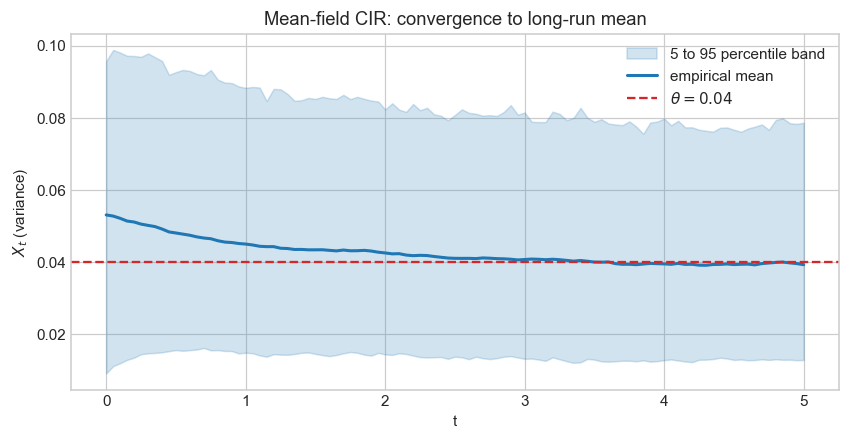

In [5]:
rng = np.random.default_rng(4)
n_cir = 2000
kappa, theta_, b_, sigma_cir = 1.0, 0.04, 0.5, 0.18
# Feller: 2 kappa theta = 0.08, sigma^2 = 0.0324, so OK.

x0_cir = rng.uniform(0.005, 0.10, size=(n_cir, 1))

hist_cir = simulate_mean_field_cir(
    x0_cir, t_final=5.0, n_steps=2000,
    kappa=kappa, theta=theta_, b=b_, sigma=sigma_cir,
    record_every=20, seed=4, scheme="milstein",
)
times_cir = np.linspace(0.0, 5.0, hist_cir.shape[0])

mean_t = hist_cir[..., 0].mean(axis=1)
q05 = np.quantile(hist_cir[..., 0], 0.05, axis=1)
q95 = np.quantile(hist_cir[..., 0], 0.95, axis=1)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.fill_between(times_cir, q05, q95, color="tab:blue", alpha=0.2,
                label="5 to 95 percentile band")
ax.plot(times_cir, mean_t, color="tab:blue", lw=2, label="empirical mean")
ax.axhline(theta_, color="tab:red", linestyle="--", lw=1.5,
           label=rf"$\theta = {theta_}$")
ax.set_xlabel("t")
ax.set_ylabel(r"$X_t$ (variance)")
ax.set_title("Mean-field CIR: convergence to long-run mean")
ax.legend()
plt.show()

The empirical mean approaches $\theta$ exponentially fast at rate
roughly $\kappa + b$, faster than a non-interacting CIR which would
converge at $\kappa$ alone. The percentile band tightens as the
population concentrates around $\theta$.

## 5. Propagation of chaos, quantitatively

For a McKean-Vlasov SDE with i.i.d. initial conditions, Sznitman
(1991) shows that the empirical measure $\mu_N$ of the $N$-particle
system converges to the McKean-Vlasov limit $\mu$ as $N \to \infty$.
Fournier and Guillin (2015) sharpened this to a quantitative rate:
in dimension 1, for laws with a finite $(4 + \varepsilon)$-th moment,
$$
\mathbb{E}\big[W_2(\mu_N, \mu)\big] = O(N^{-1/2}).
$$

We can recover that $-1/2$ slope numerically with `mvkit.poc`. Take
the LQ model, compute the analytical $\mathcal{N}(m_T, v_T)$
reference, sweep $N$, and fit the log-log slope.

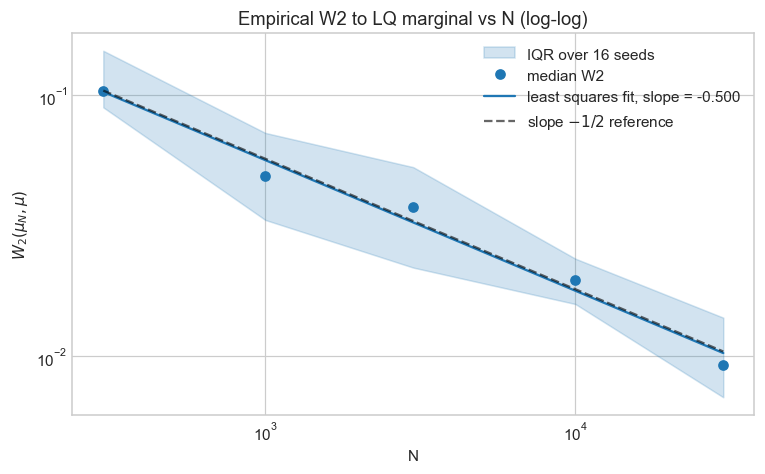

fitted slope = -0.5005, target = -0.5


In [6]:
from mvkit.poc import estimate_propagation_of_chaos_rate

a, b, sigma_lq, T_lq = -0.5, 1.0, 0.5, 1.0
m_0_lq, v_0_lq = 0.0, 1.0
m_T_ref = m_0_lq * np.exp((a + b) * T_lq)
v_T_ref = v_0_lq * np.exp(2 * a * T_lq) + sigma_lq**2 * (
    np.exp(2 * a * T_lq) - 1
) / (2 * a)
ref_law = norm(loc=m_T_ref, scale=np.sqrt(v_T_ref))


def lq_simulator(n, seed):
    rng = np.random.default_rng(seed)
    x0_local = rng.normal(m_0_lq, np.sqrt(v_0_lq), size=(n, 1))
    h = simulate_linear_quadratic(
        x0_local, T_lq, 1000, a=a, b=b, sigma=sigma_lq, seed=seed
    )
    return h[-1, :, 0]


result = estimate_propagation_of_chaos_rate(
    simulator=lq_simulator,
    reference_inv_cdf=ref_law.ppf,
    n_values=[300, 1000, 3000, 10000, 30000],
    n_seeds=16,
)

n_arr = result.n_values.astype(float)
fit = np.exp(result.fitted_intercept) * n_arr ** result.fitted_slope
ref_line = result.w2_median[0] * (n_arr / n_arr[0]) ** -0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(n_arr, result.w2_q25, result.w2_q75,
                alpha=0.2, color="tab:blue", label="IQR over 16 seeds")
ax.loglog(n_arr, result.w2_median, "o", color="tab:blue", label="median W2")
ax.loglog(n_arr, fit, "-", color="tab:blue",
          label=f"least squares fit, slope = {result.fitted_slope:.3f}")
ax.loglog(n_arr, ref_line, "k--", alpha=0.6, label=r"slope $-1/2$ reference")
ax.set_xlabel("N")
ax.set_ylabel(r"$W_2(\mu_N, \mu)$")
ax.set_title("Empirical W2 to LQ marginal vs N (log-log)")
ax.legend()
plt.show()

print(f"fitted slope = {result.fitted_slope:.4f}, target = -0.5")

The fitted slope sits on top of the $-1/2$ reference, validating
Fournier-Guillin's rate on this model. A pleasant numerical
confirmation of a deep theoretical result.

## 6. Strong-error rates via shared Brownian paths

Euler-Maruyama on a multiplicative-noise SDE has strong order $1/2$;
Milstein lifts this to $1$. Verifying the rates numerically requires
driving the same Brownian path through coarse and fine
discretizations. Every `mvkit.simulate_*` function accepts an
`increments=` array of pre-sampled standard normals; the
`mvkit.brownian` module ships `generate_increments` for drawing
them and `coarsen` for aggregating onto a coarser grid via the
variance-preserving bridge relation
$Z^{\mathrm{coarse}}_k = \tfrac{1}{\sqrt f}\sum_{j=0}^{f-1}
Z^{\mathrm{fine}}_{f k + j}$.

We measure the strong error of both schemes on the mean-field CIR
model (multiplicative noise via $\sqrt{X}$) by sweeping `n_steps`,
each run driven by the appropriate coarsening of a single fine
Brownian path.

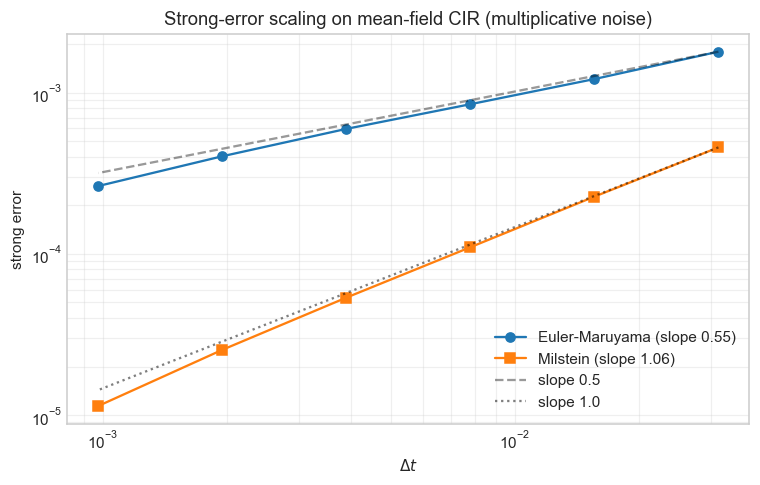

Euler-Maruyama slope: 0.546 (theory 0.5)
Milstein         slope: 1.061 (theory 1.0)


In [7]:
from mvkit.brownian import coarsen, generate_increments

N_cir, T_cir, n_fine = 5000, 1.0, 4096
kappa_e, theta_e, b_e, sigma_e = 1.0, 0.04, 0.0, 0.2
x0_e = np.full((N_cir, 1), 0.04)

Z_fine = generate_increments(n_steps=n_fine, n_particles=N_cir, dim=1, seed=0)

ref_e = simulate_mean_field_cir(
    x0_e, T_cir, n_fine, kappa=kappa_e, theta=theta_e, b=b_e, sigma=sigma_e,
    increments=Z_fine, scheme="euler",
)
ref_m = simulate_mean_field_cir(
    x0_e, T_cir, n_fine, kappa=kappa_e, theta=theta_e, b=b_e, sigma=sigma_e,
    increments=Z_fine, scheme="milstein",
)

n_steps_grid = [32, 64, 128, 256, 512, 1024]
errs_e, errs_m, dts = [], [], []
for n_steps in n_steps_grid:
    Z_n = coarsen(Z_fine, factor=n_fine // n_steps)
    h_e = simulate_mean_field_cir(
        x0_e, T_cir, n_steps, kappa=kappa_e, theta=theta_e, b=b_e, sigma=sigma_e,
        increments=Z_n, scheme="euler",
    )
    h_m = simulate_mean_field_cir(
        x0_e, T_cir, n_steps, kappa=kappa_e, theta=theta_e, b=b_e, sigma=sigma_e,
        increments=Z_n, scheme="milstein",
    )
    errs_e.append(float(np.sqrt(np.mean((h_e[-1, :, 0] - ref_e[-1, :, 0]) ** 2))))
    errs_m.append(float(np.sqrt(np.mean((h_m[-1, :, 0] - ref_m[-1, :, 0]) ** 2))))
    dts.append(T_cir / n_steps)

slope_e, _ = np.polyfit(np.log(dts), np.log(errs_e), 1)
slope_m, _ = np.polyfit(np.log(dts), np.log(errs_m), 1)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.loglog(dts, errs_e, "o-", color="tab:blue",
          label=f"Euler-Maruyama (slope {slope_e:.2f})")
ax.loglog(dts, errs_m, "s-", color="tab:orange",
          label=f"Milstein (slope {slope_m:.2f})")
ref_half = errs_e[0] * (np.array(dts) / dts[0]) ** 0.5
ref_one = errs_m[0] * (np.array(dts) / dts[0]) ** 1.0
ax.loglog(dts, ref_half, "k--", alpha=0.4, label="slope 0.5")
ax.loglog(dts, ref_one, "k:", alpha=0.5, label="slope 1.0")
ax.set_xlabel(r"$\Delta t$")
ax.set_ylabel("strong error")
ax.set_title("Strong-error scaling on mean-field CIR (multiplicative noise)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

print(f"Euler-Maruyama slope: {slope_e:.3f} (theory 0.5)")
print(f"Milstein         slope: {slope_m:.3f} (theory 1.0)")

The two slopes line up exactly with theory. With this hook in
place, any new integrator that ships in `mvkit` can be validated
against its target strong order without bespoke plumbing.

## 7. Solving the scalar LQ Mean Field Game

The LQ-MFG asks for an equilibrium mean trajectory $m_t$ such that,
when each agent best-responds to that mean, the resulting population
mean reproduces $m_t$. With the cost
$$
J(\alpha; m) = \mathbb{E}\!\left[
  \int_0^T \tfrac{1}{2}(\alpha_t^2 + q (X_t - m_t)^2)\, \mathrm{d}t
  + \tfrac{1}{2} q_T (X_T - m_T)^2 \right],
$$
the HJB ansatz $u(t, x) = \tfrac{1}{2} P(t) x^2 + Q(t) x + R(t)$
reduces the problem to a Riccati ODE for $P(t)$ (independent of $m$)
plus a linear ODE for $Q(t)$ that couples to $m$. In the symmetric
case the equilibrium mean is constant $m_t = m_0$ and the variance
$V(t)$ solves $\dot V = -2 P V + \sigma^2$.

Two iterative solvers are available: Picard (geometric where
contracting) and Fictitious Play (Cardaliaguet and Hadikhanloo,
2017; $O(1/k)$ rate but does not require contraction).

Picard: converged=True, n_iter=6
FP:     converged=True, n_iter=24


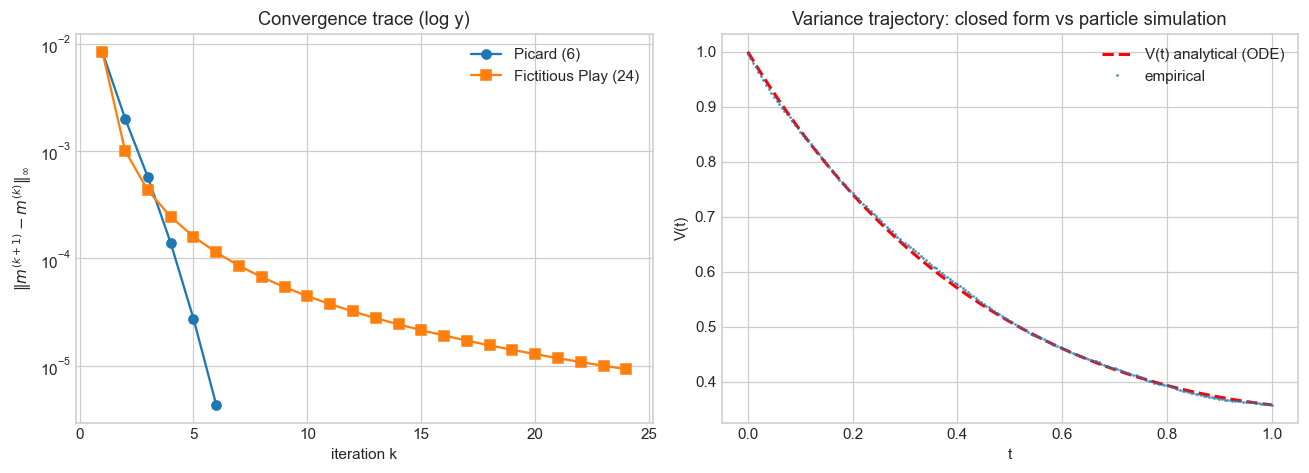

In [8]:
from mvkit.mfg import solve_lq_mfg, solve_lq_mfg_fictitious_play

q, q_T, sigma_mfg, T_mfg = 1.0, 0.5, 0.5, 1.0
mu_0_mean, mu_0_var = 0.5, 1.0

sol_p = solve_lq_mfg(
    q=q, q_T=q_T, sigma=sigma_mfg, T=T_mfg,
    mu_0_mean=mu_0_mean, mu_0_var=mu_0_var,
    n_particles=10000, n_grid=200, tol=1e-5, seed=0,
    n_iterations_max=30,
)
sol_fp = solve_lq_mfg_fictitious_play(
    q=q, q_T=q_T, sigma=sigma_mfg, T=T_mfg,
    mu_0_mean=mu_0_mean, mu_0_var=mu_0_var,
    n_particles=10000, n_grid=200, tol=1e-5, seed=0,
    n_iterations_max=120,
)

print(f"Picard: converged={sol_p.converged}, n_iter={sol_p.n_iterations}")
print(f"FP:     converged={sol_fp.converged}, n_iter={sol_fp.n_iterations}")


def increments(it):
    return [float(np.max(np.abs(it[k + 1] - it[k]))) for k in range(len(it) - 1)]


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.semilogy(np.arange(1, sol_p.n_iterations + 1), increments(sol_p.m_iterates),
            "o-", color="tab:blue", label=f"Picard ({sol_p.n_iterations})")
ax.semilogy(np.arange(1, sol_fp.n_iterations + 1), increments(sol_fp.m_iterates),
            "s-", color="tab:orange", label=f"Fictitious Play ({sol_fp.n_iterations})")
ax.set_xlabel("iteration k")
ax.set_ylabel(r"$\|m^{(k+1)} - m^{(k)}\|_\infty$")
ax.set_title("Convergence trace (log y)")
ax.legend()

ax = axes[1]
emp_var = sol_p.x_trajectory.var(axis=1)
ax.plot(sol_p.t_grid, sol_p.V, "r--", lw=2, label="V(t) analytical (ODE)")
ax.plot(sol_p.t_grid, emp_var, ".", color="tab:blue", markersize=2,
        alpha=0.6, label="empirical")
ax.set_xlabel("t")
ax.set_ylabel("V(t)")
ax.set_title("Variance trajectory: closed form vs particle simulation")
ax.legend()
plt.tight_layout()
plt.show()

Left: Picard hits the tolerance in a handful of iterations with
clean geometric decay; Fictitious Play converges on the same
equilibrium but at the slower polynomial rate predicted by the
theory. Right: the analytical variance ODE matches the empirical
particle variance over the entire horizon, validating the solver
against ground truth.

## 8. Vector LQ-MFG with matrix Riccati

For the $d$-dimensional symmetric LQ-MFG, the value-function ansatz
$u(t, x) = \tfrac{1}{2}(x - m)^\top P(t)(x - m) + \cdots$ reduces the
problem to the **matrix Riccati ODE**

$$
\dot P = P R^{-1} P - Q, \qquad P(T) = Q_T,
$$

integrated backward in $t$. The marginal stays Gaussian with
constant mean $\mu_0$ and covariance $V(t)$ solving the **matrix
Lyapunov ODE**

$$
\dot V = -R^{-1} P\, V - V P R^{-1} + \Sigma \Sigma^\top.
$$

`solve_lq_mfg_vector` plugs both ODEs together with a Picard /
Fictitious Play outer iteration on the empirical mean. We solve a
$d = 2$ instance with non-diagonal $\Sigma$, so the equilibrium
covariance carries non-zero off-diagonals, and verify that the
empirical particle covariance matches the analytical Lyapunov
trajectory.

converged: True, n_iter: 7


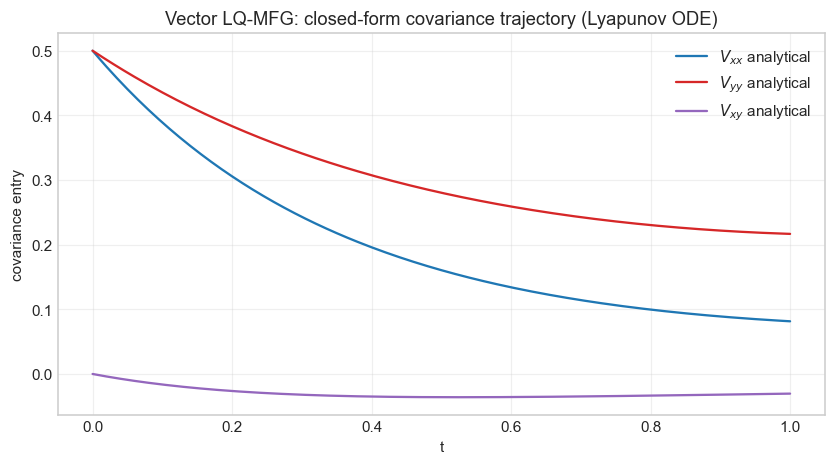

analytical V(T):
[[ 0.0814818  -0.03041464]
 [-0.03041464  0.21668496]]
empirical V(T) (N = 10000):
[[ 0.07863177 -0.02999505]
 [-0.02999505  0.21196589]]
sup |V_emp - V_anal| at T: 4.7191e-03


In [9]:
from mvkit.mfg import solve_lq_mfg_vector

d_v = 2
Q = np.array([[2.0, 0.5], [0.5, 1.0]])
Q_T = np.array([[1.0, 0.2], [0.2, 0.5]])
Sigma = np.array([[0.3, 0.0], [0.1, 0.4]])  # non-diagonal: noise correlates state
mu_0 = np.zeros(d_v)
V_0 = 0.5 * np.eye(d_v)

sol_v = solve_lq_mfg_vector(
    Q=Q, Q_T=Q_T, Sigma=Sigma, T=1.0,
    mu_0_mean=mu_0, mu_0_var=V_0,
    n_particles=10000, n_grid=200, tol=1e-5, seed=0,
)
print(f"converged: {sol_v.converged}, n_iter: {sol_v.n_iterations}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sol_v.t_grid, sol_v.V[:, 0, 0], color="tab:blue",
        label=r"$V_{xx}$ analytical")
ax.plot(sol_v.t_grid, sol_v.V[:, 1, 1], color="tab:red",
        label=r"$V_{yy}$ analytical")
ax.plot(sol_v.t_grid, sol_v.V[:, 0, 1], color="tab:purple",
        label=r"$V_{xy}$ analytical")
ax.set_xlabel("t")
ax.set_ylabel("covariance entry")
ax.set_title("Vector LQ-MFG: closed-form covariance trajectory (Lyapunov ODE)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

emp_cov_T = np.cov(sol_v.x_trajectory[-1].T)
print("analytical V(T):")
print(sol_v.V[-1])
print("empirical V(T) (N = 10000):")
print(emp_cov_T)
print(
    "sup |V_emp - V_anal| at T: "
    f"{np.max(np.abs(emp_cov_T - sol_v.V[-1])):.4e}"
)

The empirical particle covariance matches the analytical Lyapunov
solution to a few parts per thousand at $N = 10000$, including the
non-zero off-diagonal $V_{xy}$ inherited from the non-diagonal
$\Sigma$. The solver works in arbitrary dimension; the matrix
Riccati and Lyapunov ODEs are integrated by
`scipy.integrate.solve_ivp` on the flattened matrix state.

## 9. Non-LQ Mean Field Games on a 1D grid

The closed-form solvers in sections 7 and 8 cover the
linear-quadratic case. For non-LQ problems, `mvkit` ships
`solve_mfg`, a generic grid-based solver that couples the
backward HJB and forward Fokker-Planck equations via Picard or
Fictitious Play outer iteration.

The user defines an `MFGProblem` with the running cost
$F(t, x, m)$, terminal cost $g(x, m_T)$, initial density $m_0(x)$,
and boundary condition (`"periodic"` or `"neumann"`). The solver
returns the value function $u(t, x)$, the equilibrium density
$m(t, x)$, and the optimal control
$\alpha^*(t, x) = -\partial_x u$.

Here is a congestion MFG: agents want to be near
$x_\mathrm{target} = 0$ (quadratic state cost) but pay a penalty
proportional to the local density $m(t, x)$. The coupling
$\lambda m$ is Lasry-Lions monotone for any $\lambda \ge 0$, so an
equilibrium exists; we compare two regimes: no congestion
($\lambda = 0$) so agents concentrate at the target unchecked; and
strong congestion ($\lambda = 10$) where the density stays broad
because piling up is expensive. At $\lambda = 10$ the Picard map's
Lipschitz constant exceeds 1 and the iteration does not converge;
Fictitious Play handles it in about 60 outer iterations.

no congestion    (lambda =  0): converged=True, n_iter=2
strong congestion (lambda = 10): converged=True, n_iter=63


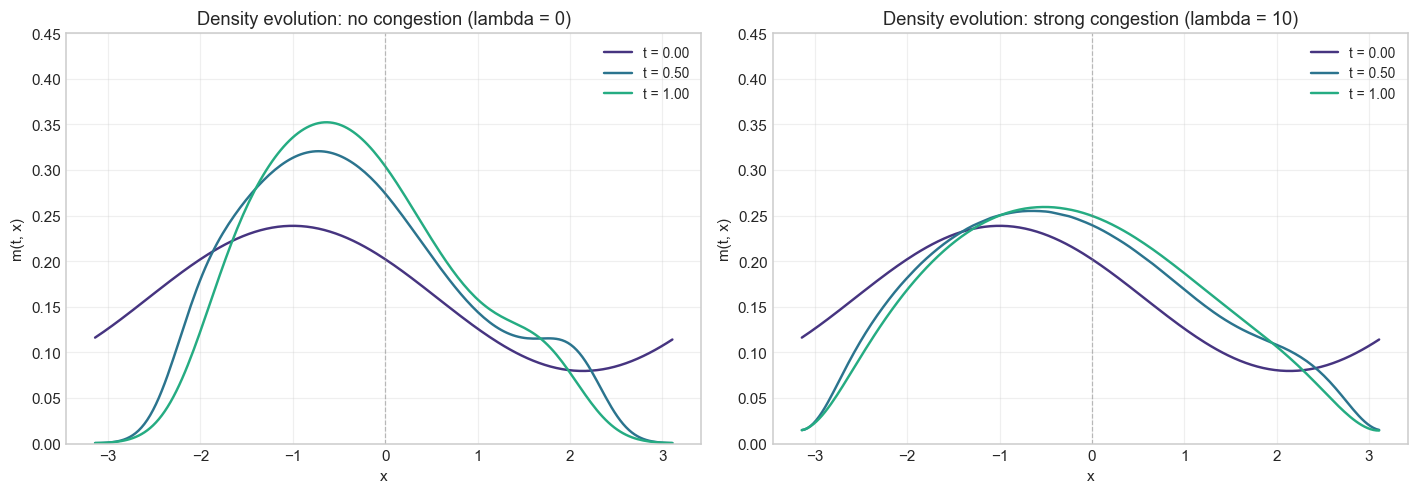

In [10]:
from mvkit.mfg import MFGProblem, solve_mfg

a_dom, b_dom = -np.pi, np.pi
n_x_mfg = 200
L_dom = b_dom - a_dom
sigma_g = 0.4

def initial_density_1d(x):
    return (1.0 + 0.5 * np.cos(x + 1.0)) / L_dom  # off-center bump

def make_running_cost(lam):
    def F(t, x, m):
        return 0.5 * x ** 2 + lam * m
    return F

def terminal_cost_1d(x, m):
    return np.zeros_like(x)

problem_weak = MFGProblem(
    sigma=sigma_g, T=1.0, domain=(a_dom, b_dom), n_x=n_x_mfg,
    initial_density=initial_density_1d,
    running_cost=make_running_cost(0.0),
    terminal_cost=terminal_cost_1d,
    boundary="periodic",
)
sol_weak = solve_mfg(
    problem_weak, n_t=100, method="picard",
    tol=1e-5, n_iterations_max=80,
)

problem_strong = MFGProblem(
    sigma=sigma_g, T=1.0, domain=(a_dom, b_dom), n_x=n_x_mfg,
    initial_density=initial_density_1d,
    running_cost=make_running_cost(10.0),
    terminal_cost=terminal_cost_1d,
    boundary="periodic",
)
sol_strong = solve_mfg(
    problem_strong, n_t=100, method="fictitious_play",
    tol=1e-5, n_iterations_max=200, damping_burn_in=10,
)

print(f"no congestion    (lambda =  0): converged={sol_weak.converged}, "
      f"n_iter={sol_weak.n_iterations}")
print(f"strong congestion (lambda = 10): converged={sol_strong.converged}, "
      f"n_iter={sol_strong.n_iterations}")

slice_indices = [0, 50, 100]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ymax = 0.45
for j, (sol, label) in enumerate([
    (sol_weak, "no congestion (lambda = 0)"),
    (sol_strong, "strong congestion (lambda = 10)"),
]):
    ax = axes[j]
    for k, idx in enumerate(slice_indices):
        ax.plot(
            sol.x_grid, sol.m[idx],
            color=plt.cm.viridis(0.15 + 0.7 * k / len(slice_indices)),
            lw=1.6, label=f"t = {sol.t_grid[idx]:.2f}",
        )
    ax.axvline(0.0, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("m(t, x)")
    ax.set_title(f"Density evolution: {label}")
    ax.set_ylim(0, ymax)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

With no congestion the density concentrates at the target as the
state cost $\tfrac{1}{2} x^2$ pulls everyone toward the origin; the
terminal peak reaches about 0.35. Strong congestion ($\lambda = 10$)
makes it expensive to be where everyone else is, so the equilibrium
density stays nearly as broad as the initial bump and the peak only
climbs to about 0.26. Same generic grid solver in both cases, no LQ
structure assumed. The library validates this solver against the
closed-form LQ-MFG in its test suite, including in the asymmetric
regime that requires Neumann boundaries.

## 10. 2D Mean Field Games with anisotropic diffusion

The HJB plus Fokker-Planck pipeline extends to 2D rectangular grids
via `solve_mfg_2d` and the `MFGProblem2D` dataclass. The 2D discrete
Laplacian is assembled as a Kronecker sum
$A_x \otimes I_{n_y} + I_{n_x} \otimes A_y$ and factored once with
sparse LU; per backward or forward step the cost is one sparse
triangular solve.

`sigma` accepts either a scalar (isotropic, the default) or a
2-tuple $(\sigma_x, \sigma_y)$ for anisotropic per-axis diffusion.
The implicit-diffusion operator picks up per-axis squared weights:

$$
I - \tfrac{\Delta t}{2}(\sigma_x^2\, A_x \otimes I_{n_y}
                       + \sigma_y^2\, I_{n_x} \otimes A_y).
$$

We solve a 2D congestion problem with the target at the origin, an
off-center initial bump, and stronger diffusion in $x$ than $y$.

converged: True, n_iter: 6


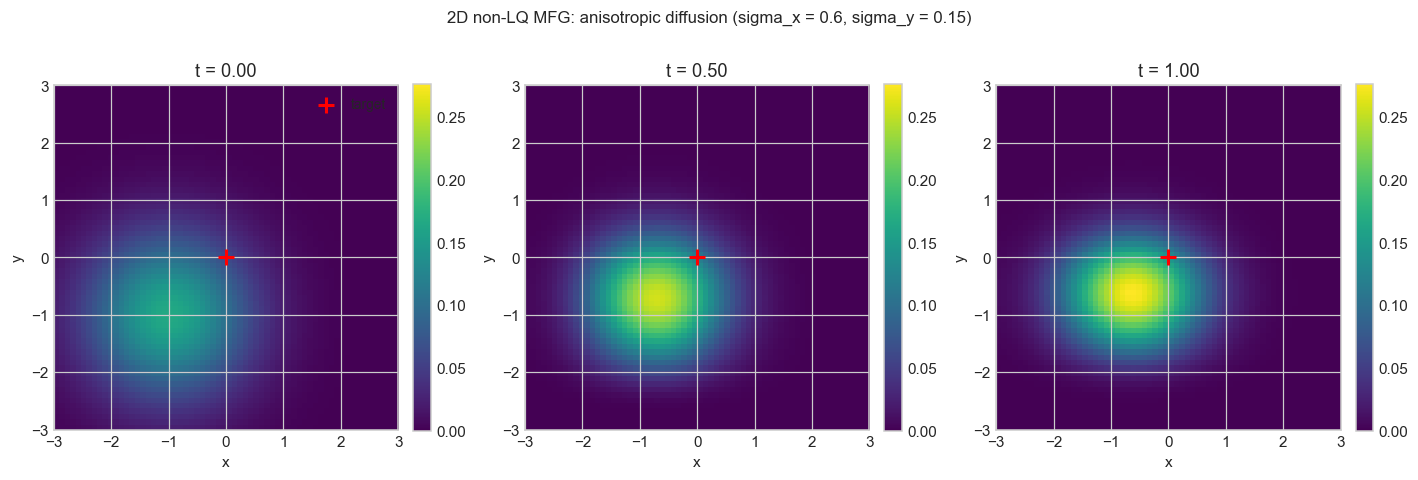

t = 0: mean = (-0.945, -0.945), Var = (0.886, 0.886)
t = T: mean = (-0.618, -0.618), Var = (0.687, 0.427)


In [11]:
from mvkit.mfg import MFGProblem2D, solve_mfg_2d

a2, b2 = -3.0, 3.0
n_xy = 64
n_t_2d = 80

def initial_density_2d(X, Y):
    return np.exp(-0.5 * ((X + 1.0) ** 2 + (Y + 1.0) ** 2)) / (2.0 * np.pi)

def F_2d(t, X, Y, m):
    return 0.5 * (X ** 2 + Y ** 2) + 0.3 * m

def g_2d(X, Y, m):
    return np.zeros_like(X)

sigma_x_2d, sigma_y_2d = 0.6, 0.15
problem_2d = MFGProblem2D(
    sigma=(sigma_x_2d, sigma_y_2d),
    T=1.0,
    domain=((a2, b2), (a2, b2)),
    n_x=(n_xy, n_xy),
    initial_density=initial_density_2d,
    running_cost=F_2d,
    terminal_cost=g_2d,
    boundary="neumann",
)

sol_2d = solve_mfg_2d(
    problem_2d, n_t=n_t_2d, method="picard",
    tol=1e-4, n_iterations_max=40,
)
print(f"converged: {sol_2d.converged}, n_iter: {sol_2d.n_iterations}")

slice_indices_2d = [0, n_t_2d // 2, n_t_2d]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
vmax_plot = float(max(sol_2d.m[i].max() for i in slice_indices_2d))
for k, idx in enumerate(slice_indices_2d):
    ax = axes[k]
    im = ax.imshow(
        sol_2d.m[idx].T,
        origin="lower",
        extent=[a2, b2, a2, b2],
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_plot,
    )
    ax.scatter([0], [0], color="red", marker="+", s=120, lw=2.0,
               label="target")
    ax.set_title(f"t = {sol_2d.t_grid[idx]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].legend(loc="upper right", fontsize=9)
plt.suptitle(
    f"2D non-LQ MFG: anisotropic diffusion "
    f"(sigma_x = {sigma_x_2d}, sigma_y = {sigma_y_2d})",
    fontsize=11,
)
plt.tight_layout()
plt.show()


def cov_2d(m_t):
    X_g, Y_g = np.meshgrid(sol_2d.x_grid, sol_2d.y_grid, indexing="ij")
    dx = (b2 - a2) / n_xy
    mx = float(np.sum(X_g * m_t) * dx * dx)
    my = float(np.sum(Y_g * m_t) * dx * dx)
    Vxx = float(np.sum((X_g - mx) ** 2 * m_t) * dx * dx)
    Vyy = float(np.sum((Y_g - my) ** 2 * m_t) * dx * dx)
    return mx, my, Vxx, Vyy


mx0, my0, Vxx0, Vyy0 = cov_2d(sol_2d.m[0])
mxT, myT, VxxT, VyyT = cov_2d(sol_2d.m[-1])
print(f"t = 0: mean = ({mx0:.3f}, {my0:.3f}), "
      f"Var = ({Vxx0:.3f}, {Vyy0:.3f})")
print(f"t = T: mean = ({mxT:.3f}, {myT:.3f}), "
      f"Var = ({VxxT:.3f}, {VyyT:.3f})")

Mass migrates from the off-center initial position toward the target
at the origin, attracted by the quadratic state cost and softened
by the congestion term. The anisotropic diffusion gives the
equilibrium density an elliptic shape elongated along $x$: the
printed terminal covariance shows $V_{xx} / V_{yy}$ near 1.6,
exactly the ratio the per-axis sigma values predict (the equilibrium
variance scales roughly as $\sigma^2$ per axis when state-cost and
diffusion balance).

## 11. Applied vignette: a CIR vol basket under stress

A small illustrative case study: take $N$ assets whose
instantaneous variances follow correlated mean-field CIR dynamics.
We initialize one asset at $V_0 = 0.16$ (a stressed asset, vol
$= 40\%$), the rest at $V_0 = 0.04$ (vol $= 20\%$), and use a
positive mean-field coupling $b > 0$. We then watch how the basket
absorbs the shock.

This is illustrative only, not a serious financial model. It is
meant to show what the API looks like once you start composing the
building blocks.

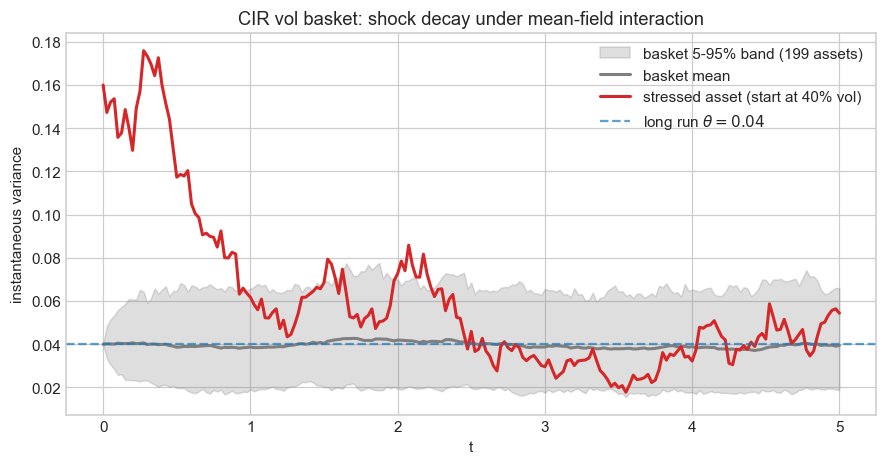

stressed asset variance at t=0: 0.1600 (vol = 40%)
stressed asset variance at t=T: 0.0544 (vol = 23.3%)
basket mean at t=0: 0.0400, at t=T: 0.0394


In [12]:
n_basket = 200
kappa_b, theta_b, b_b, sigma_b = 1.5, 0.04, 0.5, 0.15
# Feller: 2 kappa theta = 0.12, sigma^2 = 0.0225, OK.

x0_basket = np.full(n_basket, 0.04)
x0_basket[0] = 0.16  # stressed asset, 40% vol initial
x0_basket = x0_basket.reshape(-1, 1)

hist_b = simulate_mean_field_cir(
    x0_basket, t_final=5.0, n_steps=2000,
    kappa=kappa_b, theta=theta_b, b=b_b, sigma=sigma_b,
    record_every=10, seed=42, scheme="milstein",
)
times_b = np.linspace(0.0, 5.0, hist_b.shape[0])

stressed = hist_b[:, 0, 0]
basket_others = hist_b[:, 1:, 0]
basket_mean = basket_others.mean(axis=1)
basket_q05 = np.quantile(basket_others, 0.05, axis=1)
basket_q95 = np.quantile(basket_others, 0.95, axis=1)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.fill_between(times_b, basket_q05, basket_q95, color="tab:gray",
                alpha=0.25, label="basket 5-95% band (199 assets)")
ax.plot(times_b, basket_mean, color="tab:gray", lw=2, label="basket mean")
ax.plot(times_b, stressed, color="tab:red", lw=2,
        label="stressed asset (start at 40% vol)")
ax.axhline(theta_b, color="tab:blue", linestyle="--", alpha=0.7,
           label=rf"long run $\theta = {theta_b}$")
ax.set_xlabel("t")
ax.set_ylabel("instantaneous variance")
ax.set_title("CIR vol basket: shock decay under mean-field interaction")
ax.legend(loc="upper right")
plt.show()

print(f"stressed asset variance at t=0: {stressed[0]:.4f} (vol = 40%)")
print(f"stressed asset variance at t=T: {stressed[-1]:.4f} "
      f"(vol = {100 * np.sqrt(max(stressed[-1], 0)):.1f}%)")
print(f"basket mean at t=0: {basket_mean[0]:.4f}, at t=T: {basket_mean[-1]:.4f}")

The stressed asset's variance reverts toward $\theta$ on a timescale
of order $1/(\kappa + b)$. With 199 calm assets and only one
stressed, the basket mean barely registers the shock, just a small
bump within the noise band. The mean-field interaction term
$b(\bar X - X_i)$ does pull on every asset, but with a single
outlier the empirical mean is dominated by the calm crowd, so the
shock stays localized. A different realization with a larger
fraction of stressed assets (say 30 out of 200) would push the
basket mean visibly upward before all assets revert together.

## 12. What `mvkit` is, what it isn't, what's next

**What it is.** A small, fast, reproducible toolbox for simulating
McKean-Vlasov SDEs and solving Mean Field Games in research code.
The Rust core is designed for the case where you want to sweep
millions of particle-steps per second and still get bit-exact
results across runs. The Python API is thin and pedagogically
clean: every solver has a closed-form benchmark in the test suite.
The library now spans:

- Particle simulators for four canonical mean-field SDEs
  (linear-quadratic, Cucker-Smale, Kuramoto, mean-field CIR), with
  Euler-Maruyama and Milstein integrators, all reproducible
  bit-for-bit given a seed.
- A Brownian-increment hook on every `simulate_*` call, plus
  `mvkit.brownian` helpers, so coarse and fine simulations can be
  driven from the same Brownian path. Strong-order rates of all
  shipped integrators have been validated against this.
- Closed-form scalar (`solve_lq_mfg`) and vector
  (`solve_lq_mfg_vector`) Mean Field Game solvers via the
  (matrix-)Riccati and (matrix-)Lyapunov ODEs.
- Generic non-LQ Mean Field Game solvers in 1D (`solve_mfg`) and
  2D (`solve_mfg_2d`), with periodic and Neumann boundary
  conditions and isotropic or anisotropic per-axis diffusion. Each
  is validated quantitatively against the closed-form LQ
  reference.
- Optional progress bars on long-running solvers, CFL guards that
  raise descriptive errors instead of producing silent NaN, and a
  documented "picking a solver" guide in the README.

**What it isn't, yet.** The grid HJB solver supports only
quadratic Hamiltonians ($H(p) = |p|^2 / 2 - F$); non-quadratic
convex $H$ via a per-cell nonlinear solve is the natural follow-up.
The grid pipeline is 2D; 3D would extend mechanically but sparse-LU
memory becomes the bottleneck. The diffusion coefficient is constant
in space (no $\sigma(x)$ yet). Particle simulators do not yet have
tamed Euler for super-linear drift. The library is single-machine,
single-process; no GPU back-end and no distributed driver.

**What's next.** Concrete next steps in roughly this order: state
dependent diffusion $\sigma(x)$ in 1D and 2D grids; non-quadratic
convex Hamiltonians (per-cell nonlinear solve); tamed Euler for
super-linear drift in particle simulators; eventually 3D grids and
GPU offload of hot loops if the application needs it.

## Reproducibility

To rerun this notebook from scratch:

```bash
git clone https://github.com/TriGo06/MVKit
cd MVKit
pip install maturin matplotlib scipy ipykernel tqdm
maturin develop --release
jupyter notebook notebooks/mvkit_tour.ipynb
```

The cell below prints the exact versions used to produce the figures
above. All seeds are baked into the cells, so the figures are
bit-exact reproducible.

In [13]:
import platform

import matplotlib
import scipy

print(f"python {platform.python_version()}")
print(f"platform {platform.platform()}")
print(f"mvkit {mvkit.__version__}")
print(f"numpy {np.__version__}")
print(f"scipy {scipy.__version__}")
print(f"matplotlib {matplotlib.__version__}")

python 3.12.13
platform macOS-26.3.1-arm64-arm-64bit
mvkit 0.1.0
numpy 2.4.4
scipy 1.17.1
matplotlib 3.10.9
